In [7]:
import pandas as pd

df = pd.read_csv('/content/train.csv')

In [8]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [9]:
df.shape

(9800, 18)

In [10]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [12]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


Handle missing postal codes

In [13]:
df['Postal Code'].fillna(
    df['Postal Code'].median(),
    inplace=True
)

/tmp/ipykernel_3365/2006295318.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Postal Code'].fillna(


check duplicates

In [14]:
df.duplicated().sum()

np.int64(0)

convert dates

In [15]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    dayfirst=True
)

df['Ship Date'] = pd.to_datetime(
    df['Ship Date'],
    dayfirst=True
)

Create useful dashboards

In [16]:
df['Year'] = df['Order Date'].dt.year

In [17]:
df['Month'] = df['Order Date'].dt.month_name()

In [18]:
df['Quarter'] = df['Order Date'].dt.quarter

In [19]:
df['Shipping Days'] = (
    df['Ship Date'] -
    df['Order Date']
).dt.days

In [47]:
df.to_csv(
    'superstore_cleaned.csv',
    index=False
)

In [48]:
from google.colab import files

files.download(
    'superstore_cleaned.csv'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

business kpi dashboard

In [22]:
#total sales
df['Sales'].sum()

np.float64(2261536.7827000003)

In [23]:
#total orders
df['Order ID'].nunique()

4922

In [24]:
#total customers
df['Customer ID'].nunique()

793

In [25]:
#avg order value
df['Sales'].sum() / df['Order ID'].nunique()

np.float64(459.4751691791955)

Revenue analysis

In [27]:
#top categories
category_sales = (
    df.groupby('Category')['Sales']
      .sum()
      .sort_values(ascending=False)
)

category_sales

,Sales
Category,
Technology,827455.8730
Furniture,728658.5757
Office Supplies,705422.3340


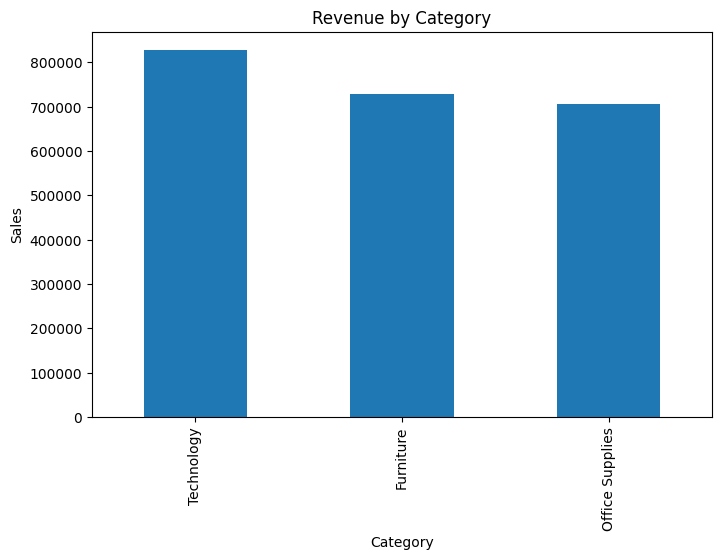

In [28]:
#visualization
import matplotlib.pyplot as plt

category_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Revenue by Category")
plt.ylabel("Sales")
plt.show()

Sub category analysis

In [29]:
subcategory_sales = (
    df.groupby('Sub-Category')['Sales']
      .sum()
      .sort_values(ascending=False)
)

subcategory_sales.head(10)

,Sales
Sub-Category,
Phones,327782.4480
Chairs,322822.7310
Storage,219343.3920
Tables,202810.6280
Binders,200028.7850
Machines,189238.6310
Accessories,164186.7000
Copiers,146248.0940
Bookcases,113813.1987


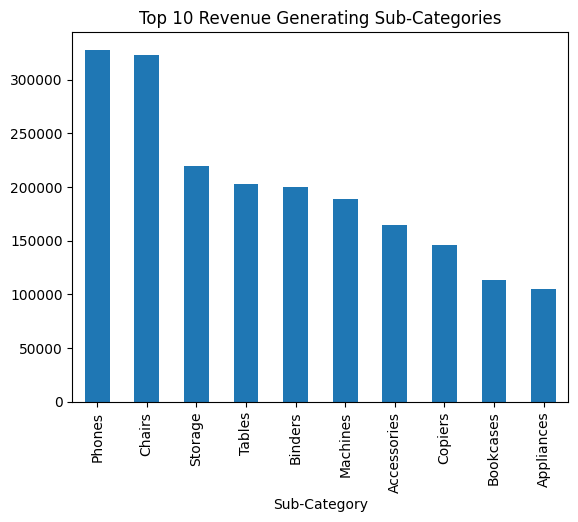

In [30]:
subcategory_sales.head(10).plot(
    kind='bar'
)

plt.title(
    "Top 10 Revenue Generating Sub-Categories"
)

plt.show()

Regional analysis

In [32]:
#revenue by region
region_sales = (
    df.groupby('Region')['Sales']
      .sum()
      .sort_values(ascending=False)
)

region_sales

,Sales
Region,
West,710219.6845
East,669518.7260
Central,492646.9132
South,389151.4590


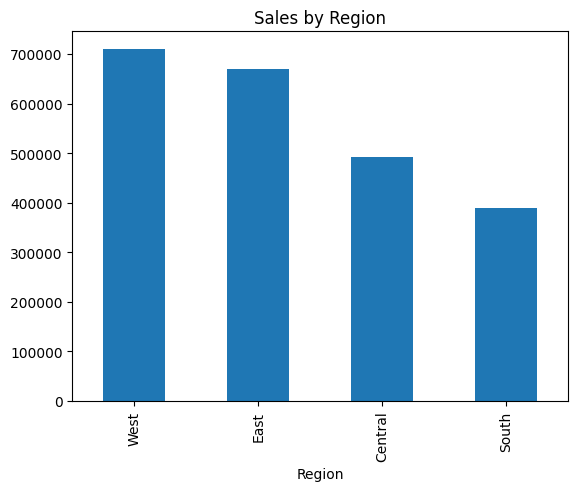

In [33]:
region_sales.plot(
    kind='bar'
)

plt.title(
    'Sales by Region'
)

plt.show()

State analysis

In [34]:
state_sales = (
    df.groupby('State')['Sales']
      .sum()
      .sort_values(ascending=False)
)

state_sales.head(10)

,Sales
State,
California,446306.4635
New York,306361.1470
Texas,168572.5322
Washington,135206.8500
Pennsylvania,116276.6500
Florida,88436.5320
Illinois,79236.5170
Michigan,76136.0740
Ohio,75130.3500


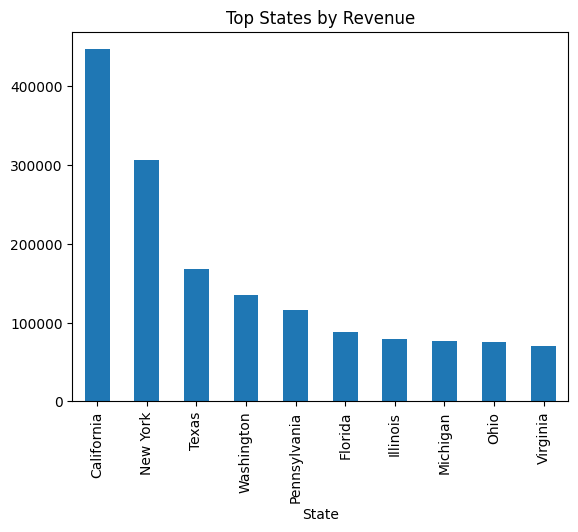

In [35]:
state_sales.head(10).plot(
    kind='bar'
)

plt.title(
    'Top States by Revenue'
)

plt.show()

Customer analysis

In [36]:
#top customers
top_customers = (
    df.groupby('Customer Name')['Sales']
      .sum()
      .sort_values(ascending=False)
)

top_customers.head(10)

,Sales
Customer Name,
Sean Miller,25043.050
Tamara Chand,19052.218
Raymond Buch,15117.339
Tom Ashbrook,14595.620
Adrian Barton,14473.571
Ken Lonsdale,14175.229
Sanjit Chand,14142.334
Hunter Lopez,12873.298
Sanjit Engle,12209.438


Segment analysis

In [37]:
segment_sales = (
    df.groupby('Segment')['Sales']
      .sum()
      .sort_values(ascending=False)
)

segment_sales

,Sales
Segment,
Consumer,1.148061e+06
Corporate,6.884941e+05
Home Office,4.249822e+05


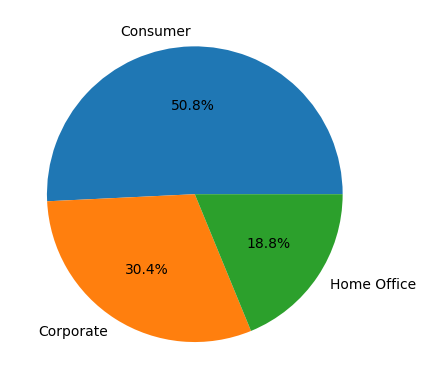

In [38]:
segment_sales.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.show()

Sales trend analysis

In [39]:
monthly_sales = (
    df.groupby(
        df['Order Date'].dt.to_period('M')
    )['Sales']
    .sum()
)

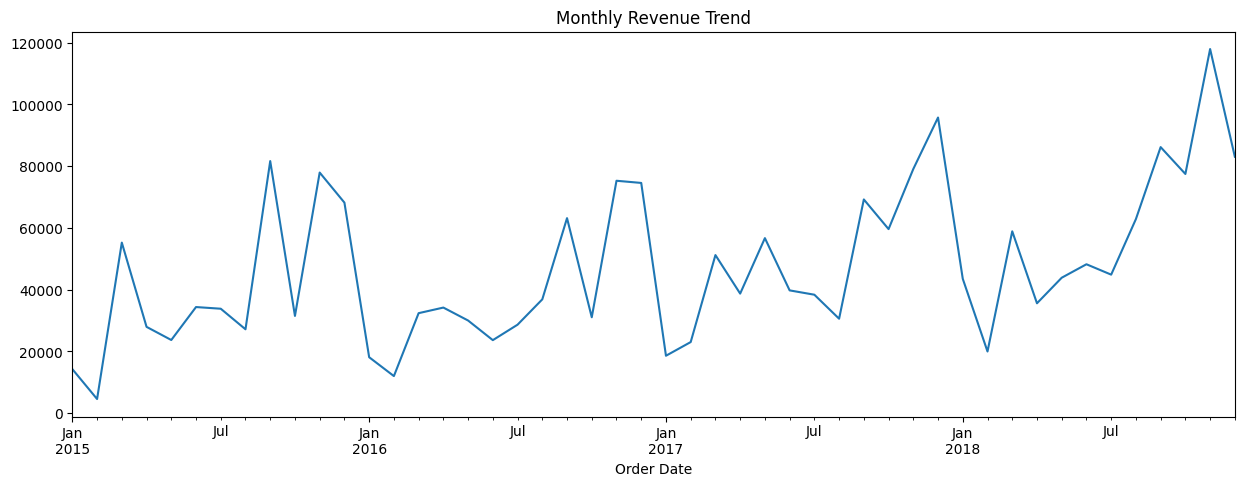

In [40]:
monthly_sales.plot(
    figsize=(15,5)
)

plt.title(
    'Monthly Revenue Trend'
)

plt.show()

Shipping performance

In [41]:
df['Shipping Days'].mean()

np.float64(3.9611224489795918)

In [42]:
df.groupby(
    'Ship Mode'
)['Shipping Days'].mean()

,Shipping Days
Ship Mode,
First Class,2.179214
Same Day,0.044610
Second Class,3.249211
Standard Class,5.008363


TOP 10 PRODUCTS

In [43]:
top_products = (
    df.groupby('Product Name')['Sales']
      .sum()
      .sort_values(ascending=False)
)

top_products.head(10)

,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
GBC DocuBind P400 Electric Binding System,17965.068


MONTHLY TREND

In [44]:
monthly_sales = (
    df.groupby(
        df['Order Date'].dt.to_period('M')
    )['Sales']
    .sum()
)

monthly_sales

,Sales
Order Date,
2015-01,14205.7070
2015-02,4519.8920
2015-03,55205.7970
2015-04,27906.8550
2015-05,23644.3030
2015-06,34322.9356
2015-07,33781.5430
2015-08,27117.5365
2015-09,81623.5268


YEARLY SALES

In [45]:
yearly_sales = (
    df.groupby(
        df['Order Date'].dt.year
    )['Sales']
    .sum()
)

yearly_sales

,Sales
Order Date,
2015,479856.2081
2016,459436.0054
2017,600192.5500
2018,722052.0192


SHIP MODE PERFORMANCE

In [46]:
df.groupby('Ship Mode')['Sales'].sum()

,Sales
Ship Mode,
First Class,3.455723e+05
Same Day,1.252190e+05
Second Class,4.499142e+05
Standard Class,1.340831e+06
